# Aprendizaje automático
> Cuaderno 4 de 5 del TFM

Parte de *dataset_modelo.csv* (cuaderno *Preprocesamiento y transformación*), entrena y compara Ridge, Random Forest y XGBoost con validación cruzada temporal y guarda el modelo final que utiliza el cuaderno de *escenarios e hipótesis*.

| Sección | Contenido | Resultado |
|---|---|---|
| 0 | Configuración y lectura del dataset | 1.256.328 registros; 13 predictoras |
| 1 | Partición dataset | Entrenamiento 2023–2024 (840.175), test 2025 (416.153), TimeSeriesSplit de 5 pliegues |
| 2 | Ridge | α = 10.000; RMSE CV = 9,66 |
| 3 | Random Forest | max_depth = 30, min_samples_leaf = 10; RMSE CV = 3,33 |
| 4 | XGBoost: optimización con Optuna (20 evaluaciones) | RMSE CV = 2,65 |
| 5 | Evaluación modelo final sobre el conjunto de test | XGBoost: RMSE = 3,33; R² = 0,967 |
| 6 | Análisis sesgo modelo | Sesgo en la franja punta laborable: 0,98 % |
| 7 | Importancia de las variables | — |
| 8 | Apéndice. Comprobación con 50 evaluaciones de Optuna | Mejora de 0,02 en RMSE de test, se mantiene el modelo de 20 |

## 0. Configuración

### Librerías

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import optuna
import joblib
import matplotlib.pyplot as plt
optuna.logging.set_verbosity(optuna.logging.WARNING)
from itertools import product
RANDOM_STATE = 42

c:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\TFM\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Parámetros y lectura de *dataset_modelo.csv*

In [3]:
# Ruta al dataset generado en el cuaderno de preprocesamiento y transformación
CARPETA_ENTRADA = Path(r'C:\\Users\\ElsaBlacoArmengod\\OneDrive - Educa Bidco\\Escritorio\\personal\\TFM\\resultados\\preprocesamiento-transformacion')
CARPETA_SALIDA   = Path(r'C:\\Users\\ElsaBlacoArmengod\\OneDrive - Educa Bidco\\Escritorio\\personal\\TFM\\resultados\\modelo')
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

RUTA_DATASET_MODELO = CARPETA_ENTRADA / 'dataset_modelo.csv'

df = pd.read_csv(RUTA_DATASET_MODELO)
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values(['id', 'fecha']).reset_index(drop=True)

VARIABLES = ['intensidad', 'ocupacion', 'hora_sin', 'hora_cos','dia_sin',  'dia_cos', 'mes_sin',  'mes_cos','es_laborable','es_verano','es_arterial','es_principal','es_secundaria']
TARGET = 'carga'

print(f"Dataset cargado: {len(df):,} registros")
print(f"Rango temporal: {df['fecha'].min()} a {df['fecha'].max()}")
print(f"Sensores: {df['id'].nunique()}  |  Tipologías: {df['tipologia'].unique().tolist()}")
print(f"Nulos: {df.isna().sum().sum()}")
print(df.columns)

Dataset cargado: 1,256,328 registros
Rango temporal: 2023-01-01 00:00:00 a 2025-12-31 23:45:00
Sensores: 12  |  Tipologías: ['Residencial', 'Principal', 'Secundaria', 'Arterial']
Nulos: 0
Index(['fecha', 'id', 'tipologia', 'intensidad', 'ocupacion', 'hora_sin',
       'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos', 'es_laborable',
       'es_verano', 'es_arterial', 'es_principal', 'es_secundaria', 'carga'],
      dtype='str')


## 1. Partición dataset

In [6]:
# Reordenar cronológicamente antes de particionar y validar
df = df.sort_values('fecha').reset_index(drop=True)

FECHA_CORTE_TEST = '2025-01-01'
df_train = df[df['fecha'] < FECHA_CORTE_TEST].copy()
df_test  = df[df['fecha'] >= FECHA_CORTE_TEST].copy()

X_train, y_train = df_train[VARIABLES], df_train[TARGET]
X_test,  y_test  = df_test[VARIABLES],  df_test[TARGET]

print("Partición:")
print(f"\nEntrenamiento y validación: {len(df_train):,} registros")
print(f"  Inicio: {df_train['fecha'].min()}  Fin: {df_train['fecha'].max()}")
print(f"Test: {len(df_test):,} registros")
print(f"  Inicio: {df_test['fecha'].min()}  Fin: {df_test['fecha'].max()}")
print(f"Total registros: {len(df_train)+len(df_test):,}")
print(X_train.columns)

Partición:

Entrenamiento y validación: 840,175 registros
  Inicio: 2023-01-01 00:00:00  Fin: 2024-12-31 23:45:00
Test: 416,153 registros
  Inicio: 2025-01-01 00:00:00  Fin: 2025-12-31 23:45:00
Total registros: 1,256,328
Index(['intensidad', 'ocupacion', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos',
       'mes_sin', 'mes_cos', 'es_laborable', 'es_verano', 'es_arterial',
       'es_principal', 'es_secundaria'],
      dtype='str')


El número de registros coincide con el esperado, de los 1.262.592 instantes de la rejilla se han eliminado los 6.264 que permanecían nulos tras la interpolación.

Los hiperparámetros de los tres modelos se ajustan mediante validación cruzada temporal de cinco pliegues (TimeSeriesSplit). La búsqueda se realiza en rejilla para Ridge y Random Forest y mediante optimización bayesiana con Optuna para XGBoost.

Definimos los cinco pliegues temporales y comprobamos que mantienen el orden temporal para evitar data leakage.

In [7]:
tss = TimeSeriesSplit(n_splits=5)
fechas = df_train['fecha'].reset_index(drop=True)

print("Análisis de los pliegues de TimeSeriesSplit sobre el conjunto de entrenamiento\n")

for i, (idx_tr, idx_val) in enumerate(tss.split(X_train), start=1):
    ini_tr,  fin_tr  = fechas.iloc[idx_tr].min(),  fechas.iloc[idx_tr].max()
    ini_val, fin_val = fechas.iloc[idx_val].min(), fechas.iloc[idx_val].max()
    print(f"Pliegue {i}:")
    print(f"   Entrenamiento desde {ini_tr} hasta {fin_tr}   ({len(idx_tr):,} registros)")
    print(f"   Validación desde {ini_val} hasta {fin_val}   ({len(idx_val):,} registros)")

Análisis de los pliegues de TimeSeriesSplit sobre el conjunto de entrenamiento

Pliegue 1:
   Entrenamiento desde 2023-01-01 00:00:00 hasta 2023-05-02 15:15:00   (140,030 registros)
   Validación desde 2023-05-02 15:30:00 hasta 2023-09-01 06:00:00   (140,029 registros)
Pliegue 2:
   Entrenamiento desde 2023-01-01 00:00:00 hasta 2023-09-01 06:00:00   (280,059 registros)
   Validación desde 2023-09-01 06:00:00 hasta 2024-01-01 02:15:00   (140,029 registros)
Pliegue 3:
   Entrenamiento desde 2023-01-01 00:00:00 hasta 2024-01-01 02:15:00   (420,088 registros)
   Validación desde 2024-01-01 02:15:00 hasta 2024-05-01 19:15:00   (140,029 registros)
Pliegue 4:
   Entrenamiento desde 2023-01-01 00:00:00 hasta 2024-05-01 19:15:00   (560,117 registros)
   Validación desde 2024-05-01 19:15:00 hasta 2024-08-31 18:45:00   (140,029 registros)
Pliegue 5:
   Entrenamiento desde 2023-01-01 00:00:00 hasta 2024-08-31 18:45:00   (700,146 registros)
   Validación desde 2024-08-31 18:45:00 hasta 2024-12-31 2

Los pliegues respetan el orden cronológico.

## 2. Ridge

La regresión Ridge incorpora una penalización sobre la suma de los cuadrados de los coeficientes, de modo que la magnitud de cada coeficiente depende de la escala en que se mide la variable asociada, luego se precisa de una estandarización previa. 

El escalado va dentro del pipeline para que en cada pliegue de la validación temporal, es scaler se ajuste solo con la proporción de entrenamiento de ese pligue.

In [5]:
print("Modelo Ridge")

pipeline_ridge = Pipeline([('scaler', StandardScaler()),('modelo', Ridge()),])

grid_ridge = {'modelo__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0,10000.0,100000.0]}

gs_ridge = GridSearchCV(pipeline_ridge, grid_ridge, cv=tss,scoring='neg_root_mean_squared_error', n_jobs=-1)
gs_ridge.fit(X_train, y_train)

print(f"Mejor alpha: {gs_ridge.best_params_['modelo__alpha']}")
print(f"RMSE CV (mejor): {-gs_ridge.best_score_:.4f}")
modelo_ridge = gs_ridge.best_estimator_

Modelo Ridge
Mejor alpha: 10000.0
RMSE CV (mejor): 9.6618


## 3. Random Forest

In [ ]:
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

grid_rf = {
    'n_estimators':     [300, 500],          # verificación de estabilización
    'max_depth':        [10, 15, 20],
    'min_samples_leaf': [20, 30, 50, 70],
    'max_features':     ['sqrt']}

gs_rf = GridSearchCV(rf, grid_rf, cv=tss,
                     scoring='neg_root_mean_squared_error', n_jobs=-1)
gs_rf.fit(X_train, y_train)

print(f"Mejores parámetros: {gs_rf.best_params_}")
print(f"RMSE CV (mejor): {-gs_rf.best_score_:.4f}")

modelo_rf = gs_rf.best_estimator_
joblib.dump(modelo_rf, CARPETA_SALIDA / 'modelo_rf.pkl')

resultados_rf = (pd.DataFrame(gs_rf.cv_results_)
                 .loc[:, ['param_n_estimators', 'param_max_depth','param_min_samples_leaf', 'mean_test_score', 'std_test_score']]
                 .assign(RMSE_medio=lambda d: -d['mean_test_score'],RMSE_desv=lambda d: d['std_test_score'])
                 .drop(columns=['mean_test_score', 'std_test_score'])
                 .sort_values('RMSE_medio')
                 .reset_index(drop=True))
print("\nTop combinaciones por RMSE de CV:")
print(resultados_rf.head(10).round(4).to_string())
resultados_rf.to_csv(CARPETA_SALIDA / 'busqueda_rf.csv', index=False)

Mejores parámetros: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 300}
RMSE CV (mejor): 3.4800

Top combinaciones por RMSE de CV:
   param_n_estimators  param_max_depth  param_min_samples_leaf  RMSE_medio  RMSE_desv
0                 300               20                      20      3.4800     0.7174
1                 500               20                      20      3.4814     0.7140
2                 300               20                      30      3.5487     0.6864
3                 300               15                      20      3.5672     0.6775
4                 500               15                      20      3.5754     0.6902
5                 500               20                      30      3.5841     0.7282
6                 300               15                      30      3.6205     0.6826
7                 500               15                      30      3.6432     0.7002
8                 500               20                      

Como dos de los parámetros seleccionados son los límites de la rejilla vamos a ampliarla a ver si se obtiene un mejor resultado:

In [ ]:
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

grid_rf = {
    'n_estimators':     [300],         
    'max_depth':        [20,30],
    'min_samples_leaf': [10,20],
    'max_features':     ['sqrt']}

gs_rf = GridSearchCV(rf, grid_rf, cv=tss,scoring='neg_root_mean_squared_error', n_jobs=-1)
gs_rf.fit(X_train, y_train)

print(f"Mejores parámetros: {gs_rf.best_params_}")
print(f"RMSE CV (mejor): {-gs_rf.best_score_:.4f}")

modelo_rf = gs_rf.best_estimator_
joblib.dump(modelo_rf, CARPETA_SALIDA / 'modelo_rf.pkl')

resultados_rf = (pd.DataFrame(gs_rf.cv_results_)
                 .loc[:, ['param_n_estimators', 'param_max_depth','param_min_samples_leaf', 'mean_test_score', 'std_test_score']]
                 .assign(RMSE_medio=lambda d: -d['mean_test_score'],RMSE_desv=lambda d: d['std_test_score'])
                 .drop(columns=['mean_test_score', 'std_test_score'])
                 .sort_values('RMSE_medio')
                 .reset_index(drop=True))
print("\nTop combinaciones por RMSE de CV:")
print(resultados_rf.head(10).round(4).to_string())
resultados_rf.to_csv(CARPETA_SALIDA / 'busqueda_rf.csv', index=False)

Mejores parámetros: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 300}
RMSE CV (mejor): 3.3280

Top combinaciones por RMSE de CV:
   param_n_estimators  param_max_depth  param_min_samples_leaf  RMSE_medio  RMSE_desv
0                 300               30                      10      3.3280     0.6929
1                 300               20                      10      3.3568     0.6997
2                 300               30                      20      3.4542     0.6836
3                 300               20                      20      3.4800     0.7174


Los valores óptimos vuelven a situarse en los extremos de la rejilla. Para evitar un proceso reiterativo y controlar el sobreajuste, se comparan, sobre los pliegues de la validación cruzada temporal, el RMSE de entrenamiento y de validación de nueve combinaciones de profundidad máxima y tamaño mínimo de hoja.

In [8]:
maxdepths = [20, 30, 40]
minleaves = [5, 10, 20]
configuraciones = [{'max_depth': d, 'min_samples_leaf': l} for d, l in product(maxdepths, minleaves)]

filas = []
for conf in configuraciones:
    rmse_train_folds, rmse_val_folds = [], []

    for idx_train, idx_val in tss.split(X_train):
        X_t, X_v = X_train.iloc[idx_train], X_train.iloc[idx_val]
        y_t, y_v = y_train.iloc[idx_train], y_train.iloc[idx_val]

        modelo = RandomForestRegressor(n_estimators=300, max_features='sqrt',random_state=RANDOM_STATE, n_jobs=-1, **conf)
        modelo.fit(X_t, y_t)

        rmse_train_folds.append(np.sqrt(mean_squared_error(y_t, modelo.predict(X_t))))
        rmse_val_folds.append(np.sqrt(mean_squared_error(y_v, modelo.predict(X_v))))

    rmse_train = np.mean(rmse_train_folds)
    rmse_val   = np.mean(rmse_val_folds)
    filas.append({
        'max_depth':        conf['max_depth'],
        'min_samples_leaf': conf['min_samples_leaf'],
        'RMSE_enetrenamiento':       round(rmse_train, 4),
        'RMSE_validación':         round(rmse_val, 4),
        'Variación':           round(rmse_val - rmse_train, 4),
        'Variación (%)':         round(100 * (rmse_val - rmse_train) / rmse_train, 2)})

tabla_var = pd.DataFrame(filas)
print(tabla_var.to_string(index=False))
tabla_var.to_csv(CARPETA_SALIDA / 'rf_variacion_configuraciones_hiperparametros', index=False)

 max_depth  min_samples_leaf  RMSE_enetrenamiento  RMSE_validación  Variación  Variación (%)
        20                 5               2.1344           3.3185     1.1841          55.48
        20                10               2.3713           3.3568     0.9854          41.56
        20                20               2.5954           3.4800     0.8846          34.08
        30                 5               2.0744           3.2596     1.1852          57.13
        30                10               2.3434           3.3280     0.9846          42.02
        30                20               2.5929           3.4542     0.8614          33.22
        40                 5               2.0756           3.2626     1.1870          57.19
        40                10               2.3441           3.3299     0.9858          42.06
        40                20               2.5931           3.4548     0.8617          33.23


El análisis de la máxima profundidad muestra que, una vez fijado el tamaño de hoja, el paso de profundidad de 20 a 30 hace que mejoren los RMSE, pero en el paso de 30 a 40 permanecen muy similares. Este estancamiento refleja que los árboles alcanzan su óptimo antes de alcanzar el límite de profundidad, por lo que ampliarlo por encima de 30 no incorpora valor al modelo, luego se selecciona 30 como profundidad máxima.

Para la elección del tamaño de hoja, tomando como referencia la profundidad seleccionada, se observa que reducir el tamaño mínimo de hoja de 20 a 10 mejora el RMSE de validación 0,126 puntos, mientras que la reducción de 10 a 5 mejora la mitad, 0,068 puntos de reducción y la diferencia entre el error de entrenamiento y validación aumenta. Esto indica que la ganancia predictiva que se ha obtenido se debe a una mayor complejidad y un mayor riesgo de sobreajuste. Se selecciona 10 como tamaño de hoja mínimo, para mantener un equilibrio entre rendimiento y generalización.

Por lo tanto, la configuración final está formada por una profundidad máxima de 30, un tamaño mínimo de hoja de 10 y 300 árboles, con selección de variables por raíz cuadrada. Este modelo alcanza un RMSE medio de validación de 3,33, lo que supone una mejora apreciable respecto a la regresión de Ridge, confirmándose así la naturaleza no lineal de la carga.

## 4. XGBoost

In [ ]:
print("XGBOOST")

def pruebas_optuna(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'learning_rate':    trial.suggest_float('learning_rate', 0.02, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1500),
        'random_state': RANDOM_STATE, 'n_jobs': -1, 'tree_method': 'hist'}
    modelo = XGBRegressor(**params)
    res = cross_val_score(modelo, X_train, y_train, cv=tss,scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -res.mean()

estudio = optuna.create_study(direction='minimize',sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
estudio.optimize(pruebas_optuna, n_trials=20, show_progress_bar=True)
params_final = {**estudio.best_params, 'random_state': RANDOM_STATE,'n_jobs': -1, 'tree_method': 'hist'}
modelo_xgb0 = XGBRegressor(**params_final)
modelo_xgb0.fit(X_train, y_train)

print(f"Mejores parámetros: {estudio.best_params}")
print(f"RMSE CV temporal (mejor): {estudio.best_value:.4f}")

joblib.dump(modelo_xgb0, CARPETA_SALIDA / 'modelo_xgb0.pkl')
print("Modelo XGBoost final entrenado con todo el conjunto de train.")

XGBOOST


Best trial: 19. Best value: 2.64751: 100%|██████████| 20/20 [48:33<00:00, 145.70s/it]


Mejores parámetros: {'max_depth': 10, 'learning_rate': 0.029289064045662273, 'subsample': 0.9485580841289939, 'colsample_bytree': 0.87853948705399, 'min_child_weight': 12, 'reg_lambda': 2.917218299774498, 'reg_alpha': 0.7983105440459752, 'n_estimators': 924}
RMSE CV temporal (mejor): 2.6475
Modelo XGBoost final entrenado con todo el conjunto de train.


## 5. Evaluación modelo final sobre el conjunto de test

In [11]:
print("Evaluación sobre el conjunto test")

def calcular_metricas(y_real, y_pred):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    carga_nonula = y_real > 1e-6                       # MAPE excluye cargas nulas
    mape = np.mean(np.abs((y_real[carga_nonula] - y_pred[carga_nonula]) / y_real[carga_nonula])) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

modelos = {'Ridge': modelo_ridge, 'Random Forest': modelo_rf, 'XGBoost': modelo_xgb0}
resultados = {n: calcular_metricas(y_test.values, m.predict(X_test))for n, m in modelos.items()}

tabla = pd.DataFrame(resultados).T[['MAE', 'RMSE', 'MAPE', 'R2']].round(4)
print("\n" + tabla.to_string())

mejor_nombre = tabla['RMSE'].idxmin()     
modelo_final = modelos[mejor_nombre]
print(f"\nMejor modelo por RMSE: {mejor_nombre}")


Evaluación sobre el conjunto test

                  MAE    RMSE     MAPE      R2
Ridge          7.0637  9.5564  74.2904  0.7313
Random Forest  2.2186  3.4794  17.1177  0.9644
XGBoost        2.0652  3.3332  16.0718  0.9673

Mejor modelo por RMSE: XGBoost


### Evaluación modelo final por tipología viaria (conjunto test)

In [12]:
df_test = df_test.copy()
df_test['pred'] = modelo_final.predict(X_test)

filas_tip = {}
for tip, grupo in df_test.groupby('tipologia'):
    filas_tip[tip] = calcular_metricas(grupo[TARGET].values, grupo['pred'].values)

tabla_tip = pd.DataFrame(filas_tip).T[['MAE', 'RMSE', 'MAPE', 'R2']].round(4)
tabla_tip = tabla_tip.sort_values('RMSE')
print("\n" + tabla_tip.to_string())
tabla_tip.to_csv(CARPETA_SALIDA / 'metricas_por_tipologia.csv')


                MAE    RMSE     MAPE      R2
Principal    1.7509  2.6484   8.5979  0.9794
Residencial  1.9434  2.9555  13.4016  0.9682
Arterial     2.2435  3.6515  21.2297  0.9477
Secundaria   2.3230  3.9190  21.4214  0.9641


## 6. Análisis sesgo modelo

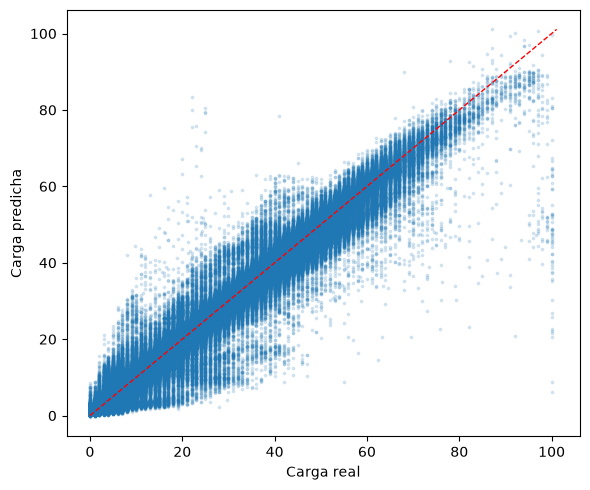

In [13]:
df_test['residuo'] = df_test[TARGET] - df_test['pred']
df_test['hora'] = df_test['fecha'].dt.hour
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_test[TARGET], df_test['pred'], s=3, alpha=0.15)
lim = [0, max(df_test[TARGET].max(), df_test['pred'].max())]
ax.plot(lim, lim, 'r--', linewidth=1)
ax.set_xlabel('Carga real')
ax.set_ylabel('Carga predicha')
plt.tight_layout()
fig.savefig(CARPETA_SALIDA / 'diagnostico_real_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
perfil_punta_laborable = df_test['hora'].between(7, 9) & (df_test['es_laborable'] == 1)

sesgo_franja = df_test.loc[perfil_punta_laborable, 'residuo'].mean()
carga_media  = df_test.loc[perfil_punta_laborable, 'carga'].mean()
sesgo_global = df_test['residuo'].mean()

print(f"Sesgo medio franja 7-9h laborables : {sesgo_franja:.4f}")
print(f"Carga media franja 7-9h laborables : {carga_media:.2f}")
print(f"Sesgo relativo franja laborables   : {100*sesgo_franja/carga_media:.2f}%")
print(f"Sesgo medio global (referencia)    : {sesgo_global:.4f}")

Sesgo medio franja 7-9h laborables : 0.3957
Carga media franja 7-9h laborables : 40.49
Sesgo relativo franja laborables   : 0.98%
Sesgo medio global (referencia)    : 0.2757


## 7. Importancia de las variables

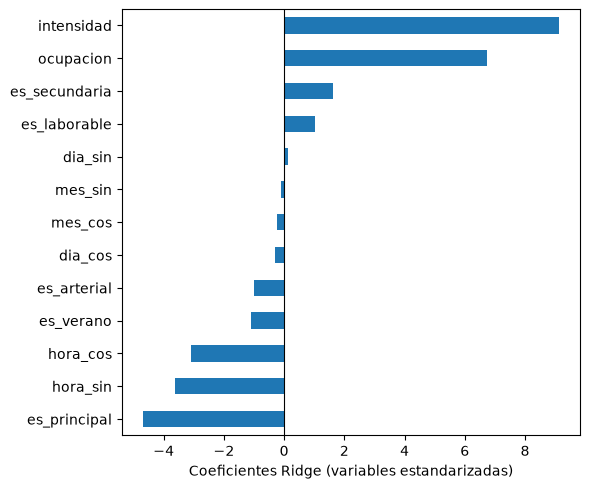

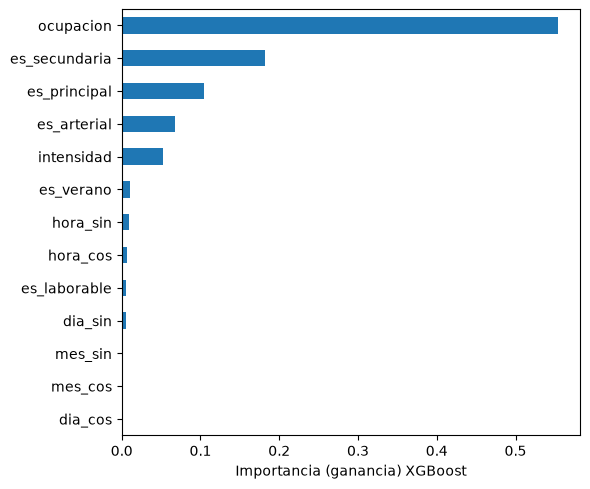

In [ ]:
# XGBoost
imp_xgb = pd.Series(modelo_xgb0.feature_importances_, index=VARIABLES).sort_values(ascending=False)

fig2, ax2 = plt.subplots(figsize=(6, 5))
imp_xgb.sort_values().plot.barh(ax=ax2)
ax2.set_xlabel('Importancia (ganancia) XGBoost')
plt.tight_layout()
fig2.savefig(CARPETA_SALIDA / 'variables_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
import shutil
shutil.copy(CARPETA_SALIDA / 'modelo_xgb0.pkl', CARPETA_SALIDA / 'modelo_xgb0_COPIA.pkl')

WindowsPath('C:/Users/ElsaBlacoArmengod/OneDrive - Educa Bidco/Escritorio/personal/TFM/resultados/modelo/modelo_xgb0_COPIA.pkl')

## 8. Apéndice. Comprobación con 50 evaluaciones de Optuna

In [ ]:
def pruebas_optuna(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'learning_rate':    trial.suggest_float('learning_rate', 0.02, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1500),
        'random_state': RANDOM_STATE, 'n_jobs': -1, 'tree_method': 'hist'}
    modelo = XGBRegressor(**params)
    res = cross_val_score(modelo, X_train, y_train, cv=tss,
                          scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -res.mean()

# Comprobación de que están definidas las variables que necesita
print(X_train.shape, y_train.shape, tss)
estudio_ext = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
estudio_ext.optimize(pruebas_optuna, n_trials=50, show_progress_bar=True)
joblib.dump(estudio_ext, CARPETA_SALIDA / 'estudio_optuna_50.pkl')
estudio = estudio_ext     

(840175, 13) (840175,) TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


Best trial: 47. Best value: 2.59472: 100%|██████████| 50/50 [1:35:43<00:00, 114.88s/it]  


Mejor RMSE validación, 20 evaluaciones: 2.6475  (debe coincidir con 2,6475)
Mejor RMSE validación, 50 evaluaciones: 2.5947  (evaluación 48)
Mejora relativa en validación: 1.99 %

                                 MAE test  RMSE test  R² test
Modelo                                                       
Modelo actual (20 evaluaciones)    2.0652     3.3332   0.9673
Comprobación (50 evaluaciones)     2.0423     3.3095   0.9678

Diferencia de RMSE en test: 0.0237


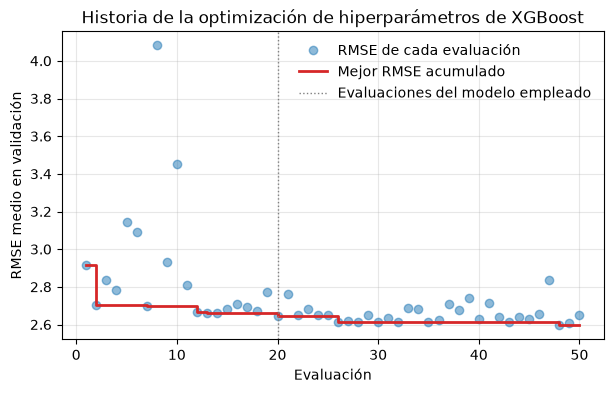

In [ ]:
import joblib
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelo actual (20 evaluaciones)
modelo_xgb0 = joblib.load(CARPETA_SALIDA / 'modelo_xgb0.pkl')

# (50 evaluaciones)
hist = estudio.trials_dataframe()
hist = hist[hist['state'] == 'COMPLETE'].reset_index(drop=True)
mejor = hist['value'].cummin()

print(f'Mejor RMSE validación, 20 evaluaciones: {mejor.iloc[19]:.4f}  (debe coincidir con 2,6475)')
print(f'Mejor RMSE validación, 50 evaluaciones: {mejor.iloc[-1]:.4f}  (evaluación {int(hist["value"].idxmin()) + 1})')
print(f'Mejora relativa en validación: {100 * (1 - mejor.iloc[-1] / mejor.iloc[19]):.2f} %\n')

# Comprobación con los hiperparámetros de 50 evaluaciones
params_50 = {**estudio.best_params, 'random_state': RANDOM_STATE, 'n_jobs': -1, 'tree_method': 'hist'}
modelo_50 = XGBRegressor(**params_50).fit(X_train, y_train)

filas = []
for nombre, m in [('Modelo actual (20 evaluaciones)', modelo_xgb0),
                  ('Comprobación (50 evaluaciones)', modelo_50)]:
    pred = m.predict(X_test)
    filas.append({'Modelo': nombre,
                  'MAE test': mean_absolute_error(y_test, pred),
                  'RMSE test': np.sqrt(mean_squared_error(y_test, pred)),
                  'R² test': r2_score(y_test, pred)})
comparacion_optuna = pd.DataFrame(filas).set_index('Modelo').round(4)
print(comparacion_optuna.to_string())
print(f"\nDiferencia de RMSE en test: "
      f"{comparacion_optuna['RMSE test'].iloc[0] - comparacion_optuna['RMSE test'].iloc[1]:.4f}")
comparacion_optuna.to_csv(CARPETA_SALIDA / 'comparacion_optuna_20_50.csv')

# Gráfico
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist['number'] + 1, hist['value'], 'o', alpha=0.5, label='RMSE de cada evaluación')
ax.step(hist['number'] + 1, mejor, where='post', color='#d62728', lw=2, label='Mejor RMSE acumulado')
ax.axvline(20, color='gray', ls=':', lw=1, label='Evaluaciones del modelo empleado')
ax.set_xlabel('Evaluación'); ax.set_ylabel('RMSE medio en validación')
ax.set_title('Historia de la optimización de hiperparámetros de XGBoost')
ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig(CARPETA_SALIDA / 'optuna_historia.png', dpi=150, bbox_inches='tight')
plt.show()